In [1]:
import cv2
import os
import random
import glob
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("Folderi u Google Drive-u:")
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
Folderi u Google Drive-u:
['java.rar', 'SP_Igor_Banovic_Domaci1.rar', 'Predavanja.rar', 'Code for Virtualbox.txt.gdoc', 'domaci', 'Domaci1_Igor_Banovic (2).rar', 'Domaci1_Igor_Banovic (1).rar', 'Domaci1_Igor_Banovic.rar', 'Domaci1_Aleksandar_Ivanovic.rar', 'internet tehnologije.rar', 'Domaci.rar', 'Igor_Banovic_Domaci01.rar', 'Igor_Banovic_Domaci02.rar', 'Igor_Banovic_Domaci02 (1).rar', 'Classroom', '7A57744C-BC95-463C-BB79-50CE9FBBA377.jpeg', '47A04F58-0A96-46AD-BAC4-E25BA81AB115.jpeg', '17231F75-207E-4C21-9899-8C6B1775F54F.jpeg', '773AAFA9-C2B1-490B-BCC3-4D14E6A4FD97.jpeg', '35CF4C8B-1A33-49C1-AB04-EA2969709ECA.jpeg', 'Domaci_Igor_Banovic.rar', 'main.c', 'main.cpp', 'IMG_3771.HEIC', 'IMG_3748.HEIC', 'IMG_3749.HEIC', 'IMG_3750.HEIC', 'IMG_3751.HEIC', 'IMG_3752.HEIC', 'IMG_3753.HEIC', 'IMG_3754.HEIC', 'IMG_3755.HEIC', 'IMG_3769.HEIC', 'IMG_3770.HEIC', 'IMG_3772.HEIC', 'IMG_3773.HEIC', 'IMG_3774.HEIC', 'IMG_3775.HEIC', 'IMG_3786.HEIC', 'IMG_3788.HEIC', 'IMG_378

In [4]:
import zipfile

putanja_zip = "/content/drive/MyDrive/datasets/Cili/CiliBolesti.zip"
putanja_izlaz = "/content/drive/MyDrive/datasets/CiliBolesti"

os.makedirs(putanja_izlaz, exist_ok=True)

with zipfile.ZipFile(putanja_zip, 'r') as zip_fajl:
    zip_fajl.extractall(putanja_izlaz)

print("Dataset je uspjesno raspakovan u:")
print(putanja_izlaz)

for korijen, direktorijumi, fajlovi in os.walk(putanja_izlaz):
    nivo = korijen.replace(putanja_izlaz, '').count(os.sep)
    uvlacenje = ' ' * 4 * nivo
    print(f"{uvlacenje}{os.path.basename(korijen)}/")
    for fajl in fajlovi[:5]:
        print(f"{uvlacenje}    {fajl}")

KeyboardInterrupt: 

Klase bolesti: ['healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish']


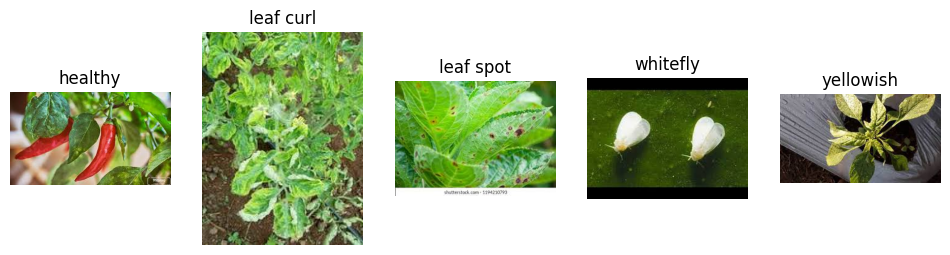

In [3]:
osnovna_putanja = "/content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train"

klase = os.listdir(osnovna_putanja)
print("Klase bolesti:", klase)

plt.figure(figsize=(12,4))

for i, klasa in enumerate(klase):
    putanje_slika = glob.glob(f"{osnovna_putanja}/{klasa}/*")

    if len(putanje_slika) == 0:
        print(f"Nema slika u klasi {klasa}")
        continue

    putanja_slike = random.choice(putanje_slika)
    slika = cv2.imread(putanja_slike)

    if slika is None:
        print(f"Ne mogu ucitati sliku: {putanja_slike}")
        continue

    slika = cv2.cvtColor(slika, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(klase), i + 1)
    plt.imshow(slika)
    plt.title(klasa)
    plt.axis("off")

plt.show()

In [4]:
putanja_trening = "/content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train"

mapiranje_simptoma = {
    "healthy": "Zdravo lisce (bez vidljivih simptoma)",
    "whitefly": "Simptomi pepelnice (bijele naslage)",
    "yellowish": "Simptomi plamenjace (zutilo)"
}

klase = list(mapiranje_simptoma.keys())

pronadjene_klase = sorted([
    d for d in os.listdir(putanja_trening)
    if os.path.isdir(os.path.join(putanja_trening, d))
])

print("Sve klase u dataset-u:", pronadjene_klase)
print("Klase koje koristimo u projektu:", klase)

for klasa in klase:
    if klasa not in pronadjene_klase:
        raise ValueError(f"Klasa '{klasa}' ne postoji u dataset-u!")

print("\nMapiranje klasa (dataset -> opis simptoma):")
for k, v in mapiranje_simptoma.items():
    print(k, "->", v)

Sve klase u dataset-u: ['healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish']
Klase koje koristimo u projektu: ['healthy', 'whitefly', 'yellowish']

Mapiranje klasa (dataset -> opis simptoma):
healthy -> Zdravo lisce (bez vidljivih simptoma)
whitefly -> Simptomi pepelnice (bijele naslage)
yellowish -> Simptomi plamenjace (zutilo)


In [5]:
putanja_trening = "/content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train"

klase = ["healthy", "whitefly", "yellowish"]

klasa = random.choice(klase)
putanja_slike = random.choice(
    glob.glob(putanja_trening + "/" + klasa + "/*")
)

slika = cv2.imread(putanja_slike)

print("Klasa:", klasa)
print("Slika:", putanja_slike)

Klasa: healthy
Slika: /content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train/healthy/Cabai sehat010.jpg


In [6]:
putanja_test = "/content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/test"

print("Putanja train:", putanja_trening)
print("Putanja test :", putanja_test)

Putanja train: /content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train
Putanja test : /content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/test


In [7]:
def primjeni_clahe(slika, clip=2, tile_x=8, tile_y=8):
    slika_lab = cv2.cvtColor(slika, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(slika_lab)

    clahe = cv2.createCLAHE(clip, (tile_x, tile_y))
    L2 = clahe.apply(L)

    lab2 = cv2.merge([L2, A, B])
    rezultat = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

    return rezultat

Klasa: yellowish
Slika: /content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train/yellowish/Cabai virus kuning44.jpg


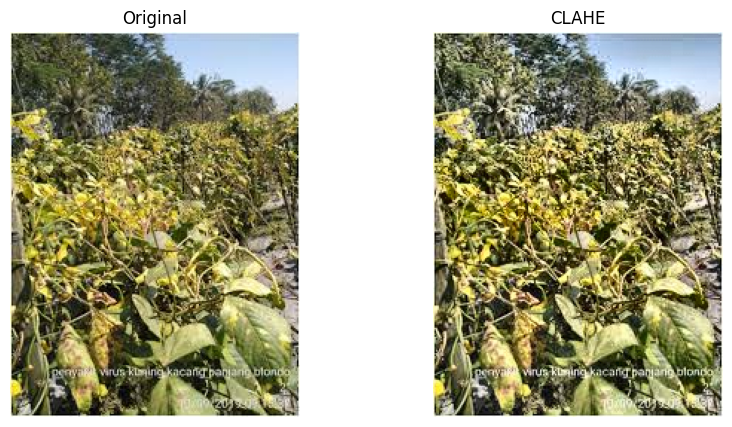

In [34]:
klasa = random.choice(klase)
putanja = random.choice(
    glob.glob(putanja_trening + "/" + klasa + "/*")
)

slika = cv2.imread(putanja)
slika_clahe = primjeni_clahe(slika)

slika_rgb = cv2.cvtColor(slika, cv2.COLOR_BGR2RGB)
slika_clahe_rgb = cv2.cvtColor(slika_clahe, cv2.COLOR_BGR2RGB)

print("Klasa:", klasa)
print("Slika:", putanja)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(slika_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(slika_clahe_rgb)
plt.title("CLAHE")
plt.axis("off")

plt.show()

In [35]:
klasa = random.choice(klase)
putanja = random.choice(glob.glob(putanja_trening + "/" + klasa + "/*"))

slika = cv2.imread(putanja)
slika_clahe = primjeni_clahe(slika)

print("Klasa:", klasa)
print("Slika:", putanja)

Klasa: yellowish
Slika: /content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train/yellowish/Cabai virus kuning34.jpg


In [36]:
def segmentacija(slika_clahe_bgr, K=3):
    lab = cv2.cvtColor(slika_clahe_bgr, cv2.COLOR_BGR2LAB)
    h, w, _ = lab.shape

    podaci = lab.reshape((-1, 3)).astype(np.float32)

    kriterijum = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)

    _, oznake, centri = cv2.kmeans(
        podaci, K, None, kriterijum, 10, cv2.KMEANS_RANDOM_CENTERS
    )

    oznake = oznake.reshape((h, w))
    centri = centri.astype(np.uint8)

    return oznake, centri

Klasa: whitefly
Slika: /content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train/whitefly/download (21).jpg
Centri (LAB): [[91, 108, 147], [152, 108, 147], [209, 111, 143]]


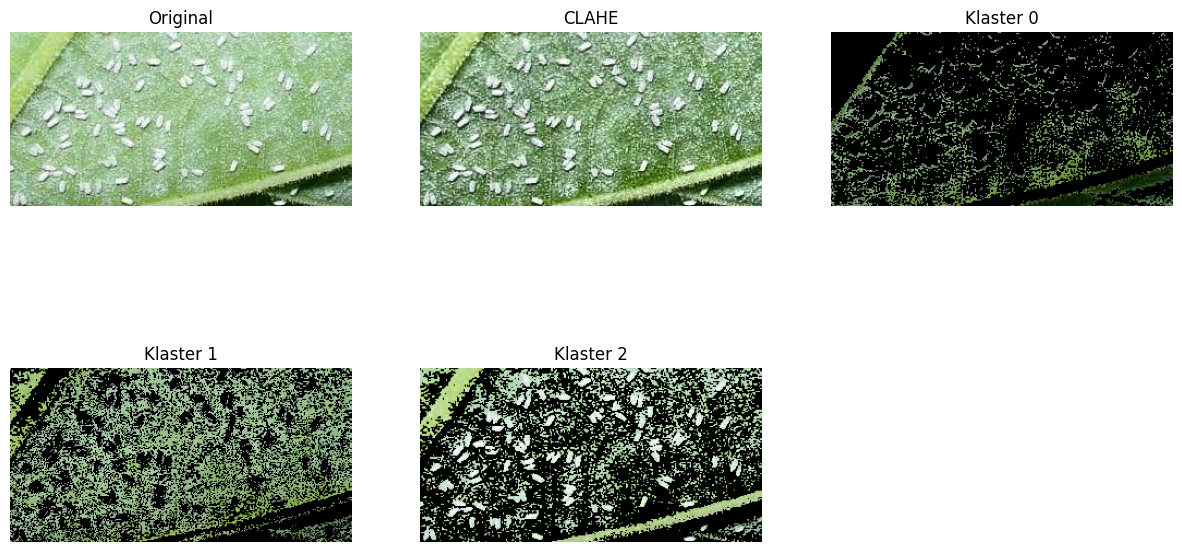

In [37]:
klasa = random.choice(klase)
putanja = random.choice(glob.glob(putanja_trening + "/" + klasa + "/*"))

slika = cv2.imread(putanja)
slika_clahe = primjeni_clahe(slika)

K = 3
oznake, centri = segmentacija(slika_clahe, K)

print("Klasa:", klasa)
print("Slika:", putanja)
print("Centri (LAB):", centri.tolist())

original_rgb = cv2.cvtColor(slika, cv2.COLOR_BGR2RGB)
clahe_rgb = cv2.cvtColor(slika_clahe, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(clahe_rgb)
plt.title("CLAHE")
plt.axis("off")

for i in range(K):
    maska = (oznake == i).astype(np.uint8) * 255
    klaster_bgr = cv2.bitwise_and(slika, slika, mask=maska)
    klaster_rgb = cv2.cvtColor(klaster_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 3)
    plt.imshow(klaster_rgb)
    plt.title("Klaster " + str(i))
    plt.axis("off")

plt.show()

In [38]:
def izaberi_klaster(slika_clahe_bgr, oznake, K):
    lab = cv2.cvtColor(slika_clahe_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0]

    srednji_L = []
    povrsine = []

    for i in range(K):
        mask = (oznake == i)
        pov = int(np.sum(mask))
        povrsine.append(pov)

        if pov > 0:
            srednji_L.append(float(np.mean(L[mask])))
        else:
            srednji_L.append(0.0)

    sortirano = sorted([(srednji_L[i], i) for i in range(K)])

    izabrani = sortirano[len(sortirano) // 2][1]

    return izabrani, srednji_L, povrsine

def napravi_masku_roi(oznake, klaster_id):
    return (oznake == klaster_id).astype(np.uint8) * 255

Izabrani klaster (ROI): 1
Srednji L po klasteru: [91.01, 152.8, 209.27]
Povrsine po klasteru: [9389, 23020, 17831]


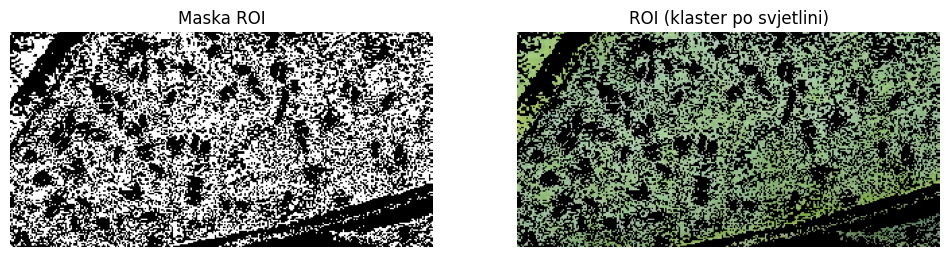

In [39]:
klaster_roi, srednji_L, povrsine = izaberi_klaster(slika_clahe, oznake, K)
maska_roi = napravi_masku_roi(oznake, klaster_roi)

print("Izabrani klaster (ROI):", klaster_roi)
print("Srednji L po klasteru:", [round(x, 2) for x in srednji_L])
print("Povrsine po klasteru:", povrsine)

roi_bgr = cv2.bitwise_and(slika, slika, mask=maska_roi)
roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(maska_roi, cmap="gray")
plt.title("Maska ROI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roi_rgb)
plt.title("ROI (klaster po svjetlini)")
plt.axis("off")

plt.show()

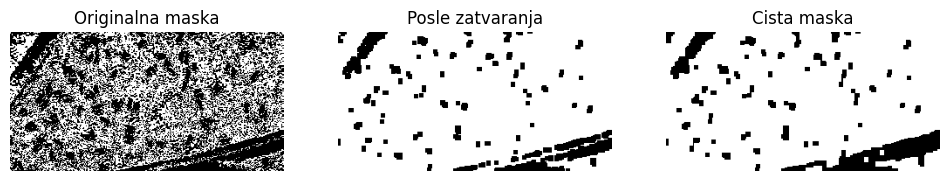

In [40]:
kernel = np.ones((5, 5), np.uint8)

maska_zatvorena = cv2.morphologyEx(maska_roi, cv2.MORPH_CLOSE, kernel)

maska_cista = cv2.morphologyEx(maska_zatvorena, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(maska_roi, cmap="gray")
plt.title("Originalna maska")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(maska_zatvorena, cmap="gray")
plt.title("Posle zatvaranja")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(maska_cista, cmap="gray")
plt.title("Cista maska")
plt.axis("off")

plt.show()

In [41]:
def izvuci_feature(slika_bgr, maska):
    if int(np.sum(maska > 0)) < 100:
        maska = np.ones(slika_bgr.shape[:2], dtype=np.uint8) * 255

    mean, std = cv2.meanStdDev(slika_bgr, mask=maska)

    mean = mean.flatten()
    std = std.flatten()

    feature = np.hstack([mean, std]).astype(np.float32)
    return feature

In [42]:
feature = izvuci_feature(slika, maska_cista)

print("Feature (6 brojeva):")
print(feature)

print("Znacenje redom:")
print("mean_B, mean_G, mean_R, std_B, std_G, std_R")

Feature (6 brojeva):
[147.54984  191.30151  158.5667    32.875862  25.247154  26.509174]
Znacenje redom:
mean_B, mean_G, mean_R, std_B, std_G, std_R


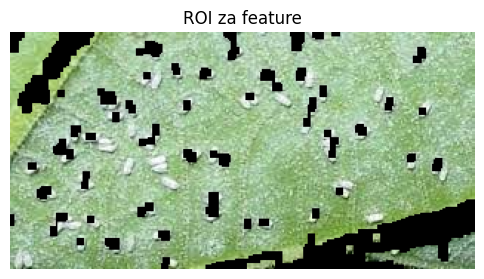

In [43]:
roi_bgr = cv2.bitwise_and(slika, slika, mask=maska_cista)
roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))
plt.imshow(roi_rgb)
plt.title("ROI za feature")
plt.axis("off")
plt.show()

In [44]:
def feature_iz_slike(putanja_slike, K=3):
    slika = cv2.imread(putanja_slike)
    if slika is None:
        return None

    slika_clahe = primjeni_clahe(slika)

    oznake, centri = segmentacija(slika_clahe, K)

    klaster_roi, srednji_L, povrsine = izaberi_klaster(slika_clahe, oznake, K)

    maska_roi = napravi_masku_roi(oznake, klaster_roi)

    kernel = np.ones((5, 5), np.uint8)
    maska_zatvorena = cv2.morphologyEx(maska_roi, cv2.MORPH_CLOSE, kernel)
    maska_cista = cv2.morphologyEx(maska_zatvorena, cv2.MORPH_OPEN, kernel)

    if int(np.sum(maska_cista > 0)) < 100:
        return None

    mean_bgr, std_bgr = cv2.meanStdDev(slika, mask=maska_cista)
    mean_bgr = mean_bgr.flatten()
    std_bgr = std_bgr.flatten()

    mean_B, mean_G, mean_R = float(mean_bgr[0]), float(mean_bgr[1]), float(mean_bgr[2])
    std_B, std_G, std_R = float(std_bgr[0]), float(std_bgr[1]), float(std_bgr[2])

    roi_bgr = cv2.bitwise_and(slika, slika, mask=maska_cista)
    mask_bool = (maska_cista > 0)

    roi_hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    H = roi_hsv[:, :, 0][mask_bool]
    S = roi_hsv[:, :, 1][mask_bool]
    V = roi_hsv[:, :, 2][mask_bool]
    if len(H) == 0:
        return None

    mean_H = float(np.mean(H))
    mean_S = float(np.mean(S))
    mean_V = float(np.mean(V))

    roi_lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L2 = roi_lab[:, :, 0][mask_bool]
    A2 = roi_lab[:, :, 1][mask_bool]
    B2 = roi_lab[:, :, 2][mask_bool]

    mean_L2 = float(np.mean(L2))
    mean_A2 = float(np.mean(A2))
    mean_B2 = float(np.mean(B2))

    feature = np.array(
        [
            mean_B, mean_G, mean_R,
            std_B, std_G, std_R,
            mean_H, mean_S, mean_V,
            mean_L2, mean_A2, mean_B2
        ],
        dtype=np.float32
    )

    return feature

In [45]:
klasa_test = random.choice(klase)
putanje = glob.glob(putanja_trening + "/" + klasa_test + "/*")
putanja_slike = random.choice(putanje)

feat = feature_iz_slike(putanja_slike, K=3)

print("Klasa:", klasa_test)
print("Slika:", putanja_slike)
print("Feature:", feat)

Klasa: whitefly
Slika: /content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/train/whitefly/images - 2021-05-19T012607.458.jpg
Feature: [ 89.530945 164.03099  123.75254   17.640331  14.256645  16.074734
  46.496586 116.853935 164.07024  160.67465  100.9847   162.16998 ]


In [46]:
def napravi_dataset(osnovna_putanja, klase, K=3, max_po_klasi=None):
    X = []
    y = []

    for idx, naziv_klase in enumerate(klase):
        folder = osnovna_putanja + "/" + naziv_klase
        slike = glob.glob(folder + "/*")

        if max_po_klasi is not None:
            slike = slike[:max_po_klasi]

        print("Klasa:", naziv_klase, "| broj slika:", len(slike))

        for putanja_slike in slike:
            feat = feature_iz_slike(putanja_slike, K=K)
            if feat is None:
                continue

            X.append(feat)
            y.append(idx)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    return X, y

In [47]:
X_train, y_train = napravi_dataset(putanja_trening, klase, K=3, max_po_klasi=None)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Primjer y_train (prvih 10):", y_train[:10])

Klasa: healthy | broj slika: 80
Klasa: whitefly | broj slika: 80
Klasa: yellowish | broj slika: 80
X_train shape: (239, 12)
y_train shape: (239,)
Primjer y_train (prvih 10): [0 0 0 0 0 0 0 0 0 0]


In [48]:
X_test, y_test = napravi_dataset(putanja_test, klase, K=3, max_po_klasi=None)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Primjer y_test (prvih 10):", y_test[:10])

Klasa: healthy | broj slika: 10
Klasa: whitefly | broj slika: 10
Klasa: yellowish | broj slika: 10
X_test shape: (30, 12)
y_test shape: (30,)
Primjer y_test (prvih 10): [0 0 0 0 0 0 0 0 0 0]


In [49]:
putanja_val = "/content/drive/MyDrive/datasets/CiliBolesti/Chili_Plant_Disease/val"

X_val, y_val = napravi_dataset(putanja_val, klase, K=3, max_po_klasi=None)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Klasa: healthy | broj slika: 10
Klasa: whitefly | broj slika: 10
Klasa: yellowish | broj slika: 10
X_val shape: (30, 12)
y_val shape: (30,)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Skaliranje gotovo.")

Skaliranje gotovo.


In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

C_vrijednosti = [0.1, 1, 5, 10, 20, 50, 100]
gamma_vrijednosti = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]

najbolja = 0
najC = None
najG = None

for C in C_vrijednosti:
    for g in gamma_vrijednosti:
        m = SVC(kernel="rbf", C=C, gamma=g, random_state=42)
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_val_scaled)
        acc = accuracy_score(y_val, pred)

        if acc > najbolja:
            najbolja = acc
            najC = C
            najG = g

print("Najbolje po VAL:")
print("C =", najC, "gamma =", najG, "val tacnost =", round(najbolja * 100, 2), "%")

Najbolje po VAL:
C = 50 gamma = 0.005 val tacnost = 70.0 %


In [52]:
svm_model = SVC(
    kernel="rbf",
    C=50,
    gamma=0.005,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model istreniran.")

SVM model istreniran.


In [53]:
y_pred = svm_model.predict(X_test_scaled)
print("Predikcije izracunate.")

Predikcije izracunate.


In [54]:
from sklearn.metrics import classification_report

print("Detaljna evaluacija po klasama:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=klase,
    digits=3
))

Detaljna evaluacija po klasama:

              precision    recall  f1-score   support

     healthy      0.875     0.700     0.778        10
    whitefly      0.800     0.800     0.800        10
   yellowish      0.833     1.000     0.909        10

    accuracy                          0.833        30
   macro avg      0.836     0.833     0.829        30
weighted avg      0.836     0.833     0.829        30



In [55]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

cm_norm_df = pd.DataFrame(
    np.round(cm_norm * 100, 1),
    index=[f"Stvarna: {k}" for k in klase],
    columns=[f"Predvidjena: {k}" for k in klase]
)

print("Matrica konfuzije (%):")
cm_norm_df

Matrica konfuzije (%):


,Predvidjena: healthy,Predvidjena: whitefly,Predvidjena: yellowish
Stvarna: healthy,70.0,20.0,10.0
Stvarna: whitefly,10.0,80.0,10.0
Stvarna: yellowish,0.0,0.0,100.0


from matplotlib import pyplot as plt
_df_0['Predvidjena: healthy'].plot(kind='hist', bins=20, title='Predvidjena: healthy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Predvidjena: whitefly'].plot(kind='hist', bins=20, title='Predvidjena: whitefly')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Predvidjena: yellowish'].plot(kind='hist', bins=20, title='Predvidjena: yellowish')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_12['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_12, x='Predvidjena: healthy', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_13['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_13, x='Predvidjena: whitefly', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='Predvidjena: yellowish', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

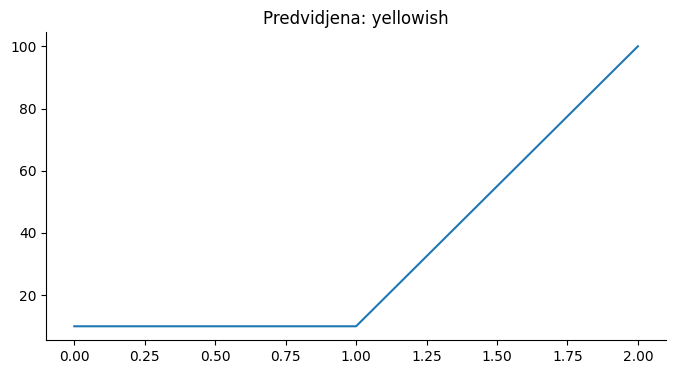

In [57]:
from matplotlib import pyplot as plt
_df_11['Predvidjena: yellowish'].plot(kind='line', figsize=(8, 4), title='Predvidjena: yellowish')
plt.gca().spines[['top', 'right']].set_visible(False)

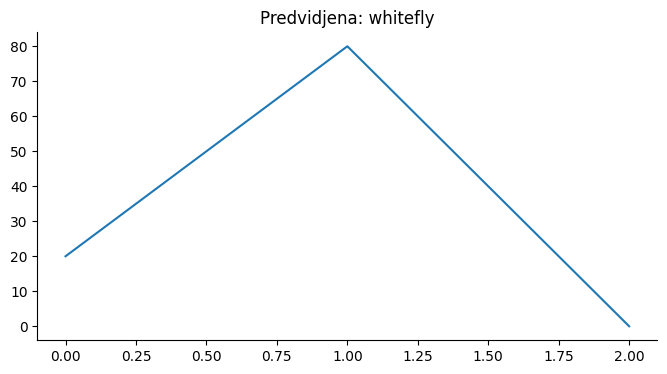

In [58]:
from matplotlib import pyplot as plt
_df_10['Predvidjena: whitefly'].plot(kind='line', figsize=(8, 4), title='Predvidjena: whitefly')
plt.gca().spines[['top', 'right']].set_visible(False)

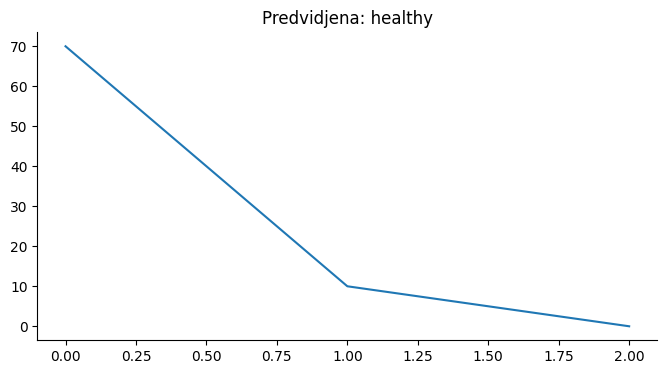

In [59]:
from matplotlib import pyplot as plt
_df_9['Predvidjena: healthy'].plot(kind='line', figsize=(8, 4), title='Predvidjena: healthy')
plt.gca().spines[['top', 'right']].set_visible(False)

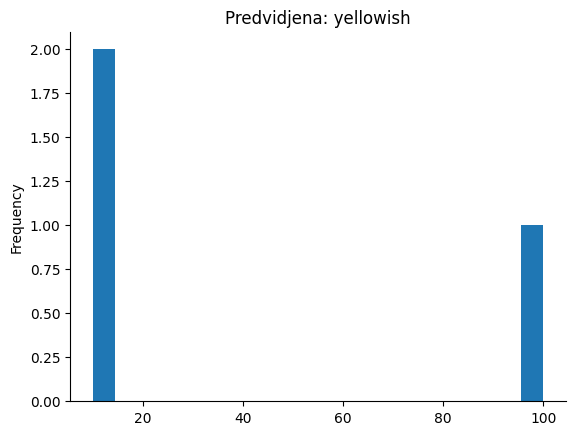

In [60]:
from matplotlib import pyplot as plt
_df_2['Predvidjena: yellowish'].plot(kind='hist', bins=20, title='Predvidjena: yellowish')
plt.gca().spines[['top', 'right',]].set_visible(False)

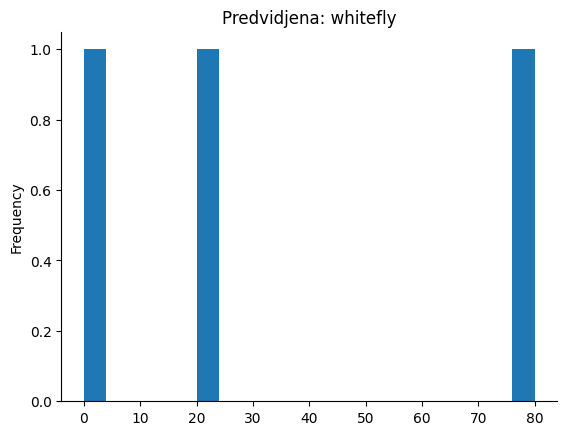

In [62]:
from matplotlib import pyplot as plt
_df_1['Predvidjena: whitefly'].plot(kind='hist', bins=20, title='Predvidjena: whitefly')
plt.gca().spines[['top', 'right',]].set_visible(False)

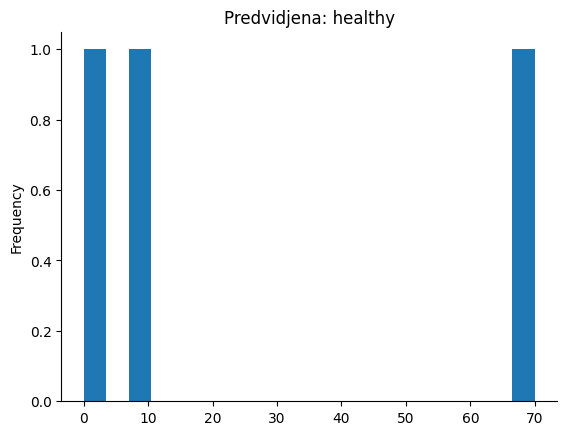

In [56]:
from matplotlib import pyplot as plt
_df_0['Predvidjena: healthy'].plot(kind='hist', bins=20, title='Predvidjena: healthy')
plt.gca().spines[['top', 'right',]].set_visible(False)